In [39]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
import numpy as np



In [40]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


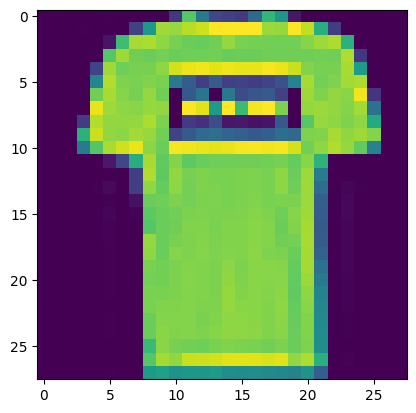

In [41]:
# Fashion MNIST labels
# 0 = T-shirt/top
# 1 = Trouser
# 2 = Pullover
# 3 = Dress
# 4 = Coat
# 5 = Sandal
# 6 = Shirt
# 7 = Sneaker
# 8 = Bag
# 9 = Ankle boot

plt.imshow(x_train[1])
plt.show()

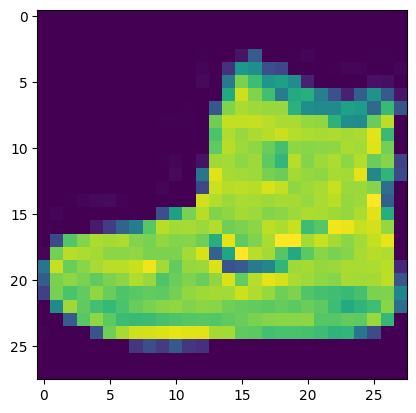

In [42]:
plt.imshow(x_train[0])
plt.show()

In [43]:
x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0
# Reshape dataset into 4D tensor
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [44]:
# Display dataset shapes
print("x_train shape:", x_train.shape)
print("x_test shape :", x_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

x_train shape: (60000, 28, 28, 1)
x_test shape : (10000, 28, 28, 1)
y_train shape: (60000,)
y_test shape : (10000,)


In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.25),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [47]:
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [49]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 74s 38ms/step - accuracy: 0.8003 - loss: 0.5425 - val_accuracy: 0.8622 - val_loss: 0.3770
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 37ms/step - accuracy: 0.8688 - loss: 0.3619 - val_accuracy: 0.8850 - val_loss: 0.3138
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.8849 - loss: 0.3175 - val_accuracy: 0.8962 - val_loss: 0.2845
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 69s 37ms/step - accuracy: 0.8919 - loss: 0.2928 - val_accuracy: 0.8967 - val_loss: 0.2751
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 35ms/step - accuracy: 0.8986 - loss: 0.2744 - val_accuracy: 0.9060 - val_loss: 0.2550
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.9006 - loss: 0.2640 - val_accuracy: 0.9086 - val_loss: 0.2475
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 34ms/step - accuracy: 0.9071 - loss: 0.2493 - val_accuracy: 0.9075 - val_loss: 0.2489
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.9090 -

In [50]:
test_loss, test_acc = model.evaluate(
    x_test,
    y_test
)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9137 - loss: 0.2338
Test Accuracy: 0.9136999845504761
Test Loss: 0.23384548723697662


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


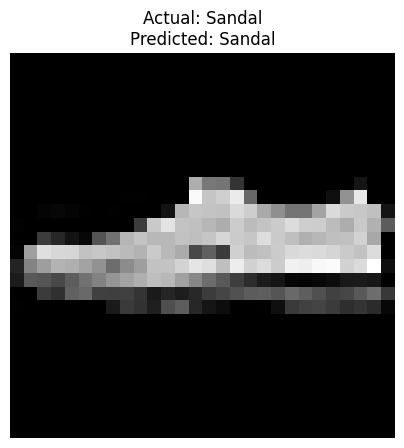

Confidence scores for all 10 classes:
[5.7563716e-07 7.4231754e-10 1.0447895e-08 2.7964177e-08 6.1579503e-10
 7.9934949e-01 7.6149718e-09 2.0003214e-01 1.4416919e-07 6.1765756e-04]


In [51]:
# 1. Pick a random index from the test set
random_index = np.random.randint(0, len(x_test))
sample_image = x_test[random_index]
true_label = y_test[random_index]

# 2. Reshape the image to (1, 28, 28, 1)
# The model expects a batch, so we add a batch dimension of 1
prediction_input = sample_image.reshape(1, 28, 28, 1)

# 3. Make the prediction
predictions = model.predict(prediction_input)
predicted_label = np.argmax(predictions) # Get the index of the highest probability

# 4. Define the class names for display
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 5. Visualize the result
plt.figure(figsize=(5,5))
plt.imshow(sample_image.reshape(28, 28), cmap='gray')
plt.title(f"Actual: {class_names[true_label]}\nPredicted: {class_names[predicted_label]}")
plt.axis('off')
plt.show()

print(f"Confidence scores for all 10 classes:\n{predictions[0]}")